# MWOW Data Access Examples

This notebook demonstrates three common workflows for MWOW (Multi-sensor Worldwide Ocean Winds) data:

1. **Point time series** -- extract wind data at a single lat/lon across all orbits
2. **Ship track matching** -- match a moving platform's positions to the nearest MWOW observations
3. **Regional selection** -- select a geographic box and browse individual orbit passes

The examples below use raw xarray/numpy calls so you can see exactly what is happening.
For a more concise approach, the **`mwow_tools`** package wraps these patterns into
reusable functions:

```python
from mwow_tools import open_mwow_files, select_point, match_ship_track, select_region

ds = open_mwow_files("/path/to/mwow/*.nc")
ds_point = select_point(ds, lat=-54, lon=90)
ds_ship  = match_ship_track(ds, lats, lons, times)
ds_box   = select_region(ds, lat_center=-38, lon_center=70)
```

Install with: `pip install -e /path/to/mwow-user-tools`

In [2]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import netCDF4 as nc


## Start by opening a file or a set of files. 
Data from a set of files will be automatically stacked along the 'orbit' dimension.
Data will be lazily loaded, meaning nothing will be loaded into memory until processing time. 
Chunking is set to 'auto' since MWOW files are pre-chunked by defualt.

In [134]:
folder = '/path_to_mwow_data/'

paths = np.sort(glob.glob(folder + '/*.nc'))

ds = xr.open_mfdataset(paths,chunks="auto")
display(ds.compute())

<xarray.Dataset>
Dimensions:                (longitude: 2880, latitude: 1440, orbit: 35)
Coordinates:
  * latitude               (latitude) float32 -89.94 -89.81 ... 89.81 89.94
  * longitude              (longitude) float32 -179.9 -179.8 ... 179.8 179.9
Dimensions without coordinates: orbit
Data variables:
    time                   (longitude, latitude, orbit) datetime64[ns] NaT .....
    orbit_start_time       (orbit) datetime64[ns] 2026-03-21T18:15:04 ... 202...
    wind_speed             (longitude, latitude, orbit) float32 nan nan ... nan
    wind_direction         (longitude, latitude, orbit) float32 nan nan ... nan
    wind_speed_uncert      (longitude, latitude, orbit) float32 nan nan ... nan
    wind_direction_uncert  (longitude, latitude, orbit) float32 nan nan ... nan
    quality_indicator      (longitude, latitude, orbit) float32 nan nan ... nan
    sensor_id              (longitude, latitude, orbit) float32 nan nan ... nan
Attributes: (12/36)
    Conventions:                CF-1.7, ACDD-1.3, ISO-8601
    title:                      MWOW 6-Hourly Global Ocean Wind with Expanded...
    summary:                    This dataset contains Level 3 ocean surface w...
    project:                    Multi-sensor Worldwide Ocean Winds
    acknowledgement:            This project is funded by the Satellite Needs...
    program:                    Satellite Needs Working Group
    ...                         ...
    geospatial_lon_min:         -180.0
    geospatial_lon_max:         180.0
    geospatial_lat_min:         -90.0
    geospatial_lat_max:         90.0
    geospatial_lon_resolution:  0.125
    geospatial_lat_resolution:  0.125

## Example 1: Pull out all at a single lat/lon coordinate 
Will return a dataset containing all data contained at a lat/lon coordinate indexed by orbit (time)

In [65]:
ds_point = ds.sel(latitude=-54,longitude=90,method='nearest')

display(ds_point)

<xarray.Dataset>
Dimensions:                (orbit: 35)
Coordinates:
    latitude               float32 -53.94
    longitude              float32 90.06
Dimensions without coordinates: orbit
Data variables:
    time                   (orbit) datetime64[ns] dask.array<chunksize=(17,), meta=np.ndarray>
    orbit_start_time       (orbit) datetime64[ns] dask.array<chunksize=(35,), meta=np.ndarray>
    wind_speed             (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
    wind_direction         (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
    wind_speed_uncert      (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
    wind_direction_uncert  (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
    quality_indicator      (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
    sensor_id              (orbit) float32 dask.array<chunksize=(21,), meta=np.ndarray>
Attributes: (12/36)
    Conventions:                CF-1.7, ACDD-1.3, ISO-8601
    title:                      MWOW 6-Hourly Global Ocean Wind with Expanded...
    summary:                    This dataset contains Level 3 ocean surface w...
    project:                    Multi-sensor Worldwide Ocean Winds
    acknowledgement:            This project is funded by the Satellite Needs...
    program:                    Satellite Needs Working Group
    ...                         ...
    geospatial_lon_min:         -180.0
    geospatial_lon_max:         180.0
    geospatial_lat_min:         -90.0
    geospatial_lat_max:         90.0
    geospatial_lon_resolution:  0.125
    geospatial_lat_resolution:  0.125

## Plot the point data over time

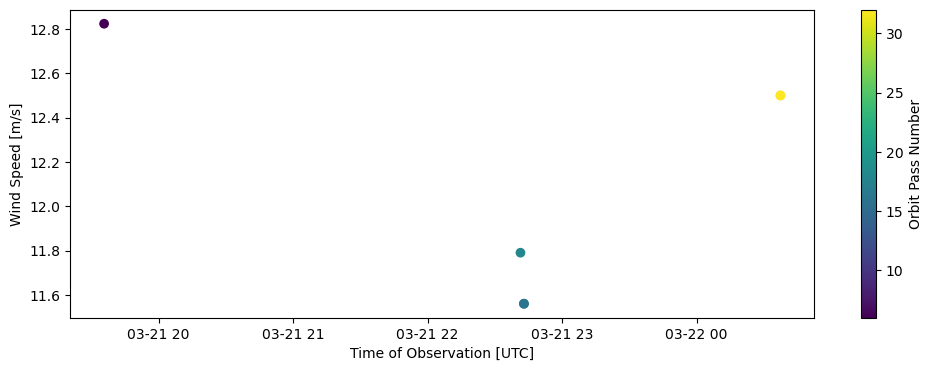

In [85]:
plt.figure(figsize=(12,4))
plt.scatter(ds_point.time,ds_point.wind_speed,c=ds_point.orbit)
plt.xlabel('Time of Observation [UTC]')
plt.ylabel('Wind Speed [m/s]')
plt.colorbar(label='Orbit Pass Number')
plt.show()

## Example 2: Pull out a set of lat/lon/time points, like from a moving ship.
Set up sampling data first (ship-like). Replace with user-provided data.

In [182]:
# Set up some input sample data as a time-series of points taken from moving lat/lon locations

ship_lat = np.array([-38.1, -38.2, -38.3, -38.4, -38.5])
ship_lon = np.array([70.0, 70.1, 70.2, 70.3, 70.4])
ship_time = np.array([
    '2026-03-21T19:35:36',
    '2026-03-21T20:35:36',
    '2026-03-21T21:35:36',
    '2026-03-22T22:35:36',
    '2026-03-23T23:35:36'
], dtype='datetime64[ns]')

# Add the data to a xarray DataArray with a single dimension "point"
# One could alternatively use numpy or some other interpolator, but 
# this setup allows us to interpolate every variable in the MWOW
# dataset all at once and keep the metadata.

point = xr.DataArray(np.arange(len(ship_lat)), dims='point')
ship_lat_da = xr.DataArray(ship_lat, dims='point', coords={'point': point})
ship_lon_da = xr.DataArray(ship_lon, dims='point', coords={'point': point})
ship_time_da = xr.DataArray(ship_time, dims='point', coords={'point': point})


## Perform the sampling 

In [192]:
# Select the nearest lat/lon from MWOW for each ship point

ds_ll = ds.sel(
    latitude=ship_lat_da,
    longitude=ship_lon_da,
    method='nearest'
)

# At this stage we will have a dataset corresponding to the lat/lon ship points
# taken at each orbit in the MWOW files. Now we need to find the right orbit (time)

# Find the time difference between MWOW time and ship time for each point/orbit
dt = abs(ds_ll['time'] - ship_time_da)

# Get the index of the nearest MWOW orbit for each ship point
dt_filled = dt.fillna(np.timedelta64(99, 'D')) # big time difference to fill missing data
orbit_idx = dt_filled.argmin(dim='orbit').compute()

# Now select only the nearest-time orbit for each point
ds_ship = ds_ll.isel(orbit=orbit_idx)

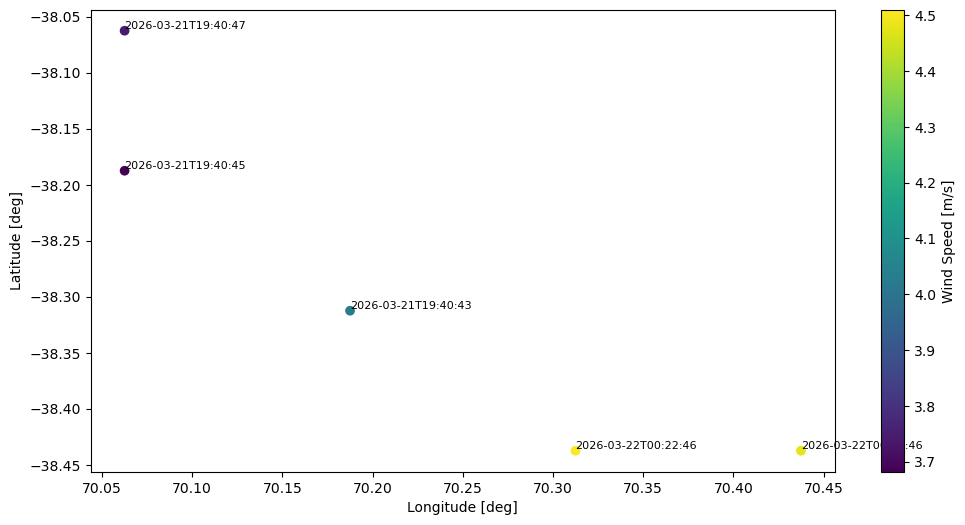

In [193]:
plt.figure(figsize=(12,6))
sc = plt.scatter(ds_ship.longitude, ds_ship.latitude, c=ds_ship.wind_speed)

for lon, lat, t in zip(ds_ship.longitude.values, ds_ship.latitude.values, ds_ship.time.values):
    label = np.datetime_as_string(t, unit='s')
    plt.text(lon, lat, label, fontsize=8, ha='left', va='bottom')

plt.xlabel('Longitude [deg]')
plt.ylabel('Latitude [deg]')
plt.colorbar(sc, label='Wind Speed [m/s]')
plt.show()

## Example 3: Select an arbitrary region surrounding a lat/lon coordinate

In [175]:
lat_center = -38
lon_center = 70

lon_size = 5 # degrees
lat_size = 5 # degrees

# Select our lat/lon region
ds_region = ds.sel(latitude=slice(lat_center - lat_size,lat_center + lat_size),
                   longitude=slice(lon_center - lon_size,lon_center + lon_size))

# Drop the obrits that didn't have any data in this region.
valid_orbit = ds_region.wind_speed.notnull().any(dim=('latitude','longitude')).compute()
ds_region = ds_region.isel(orbit=valid_orbit)

display(ds_region)

<xarray.Dataset>
Dimensions:                (longitude: 80, latitude: 80, orbit: 6)
Coordinates:
  * latitude               (latitude) float32 -42.94 -42.81 ... -33.19 -33.06
  * longitude              (longitude) float32 65.06 65.19 65.31 ... 74.81 74.94
Dimensions without coordinates: orbit
Data variables:
    time                   (longitude, latitude, orbit) datetime64[ns] dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    orbit_start_time       (orbit) datetime64[ns] dask.array<chunksize=(6,), meta=np.ndarray>
    wind_speed             (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    wind_direction         (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    wind_speed_uncert      (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    wind_direction_uncert  (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    quality_indicator      (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
    sensor_id              (longitude, latitude, orbit) float32 dask.array<chunksize=(80, 80, 1), meta=np.ndarray>
Attributes: (12/36)
    Conventions:                CF-1.7, ACDD-1.3, ISO-8601
    title:                      MWOW 6-Hourly Global Ocean Wind with Expanded...
    summary:                    This dataset contains Level 3 ocean surface w...
    project:                    Multi-sensor Worldwide Ocean Winds
    acknowledgement:            This project is funded by the Satellite Needs...
    program:                    Satellite Needs Working Group
    ...                         ...
    geospatial_lon_min:         -180.0
    geospatial_lon_max:         180.0
    geospatial_lat_min:         -90.0
    geospatial_lat_max:         90.0
    geospatial_lon_resolution:  0.125
    geospatial_lat_resolution:  0.125

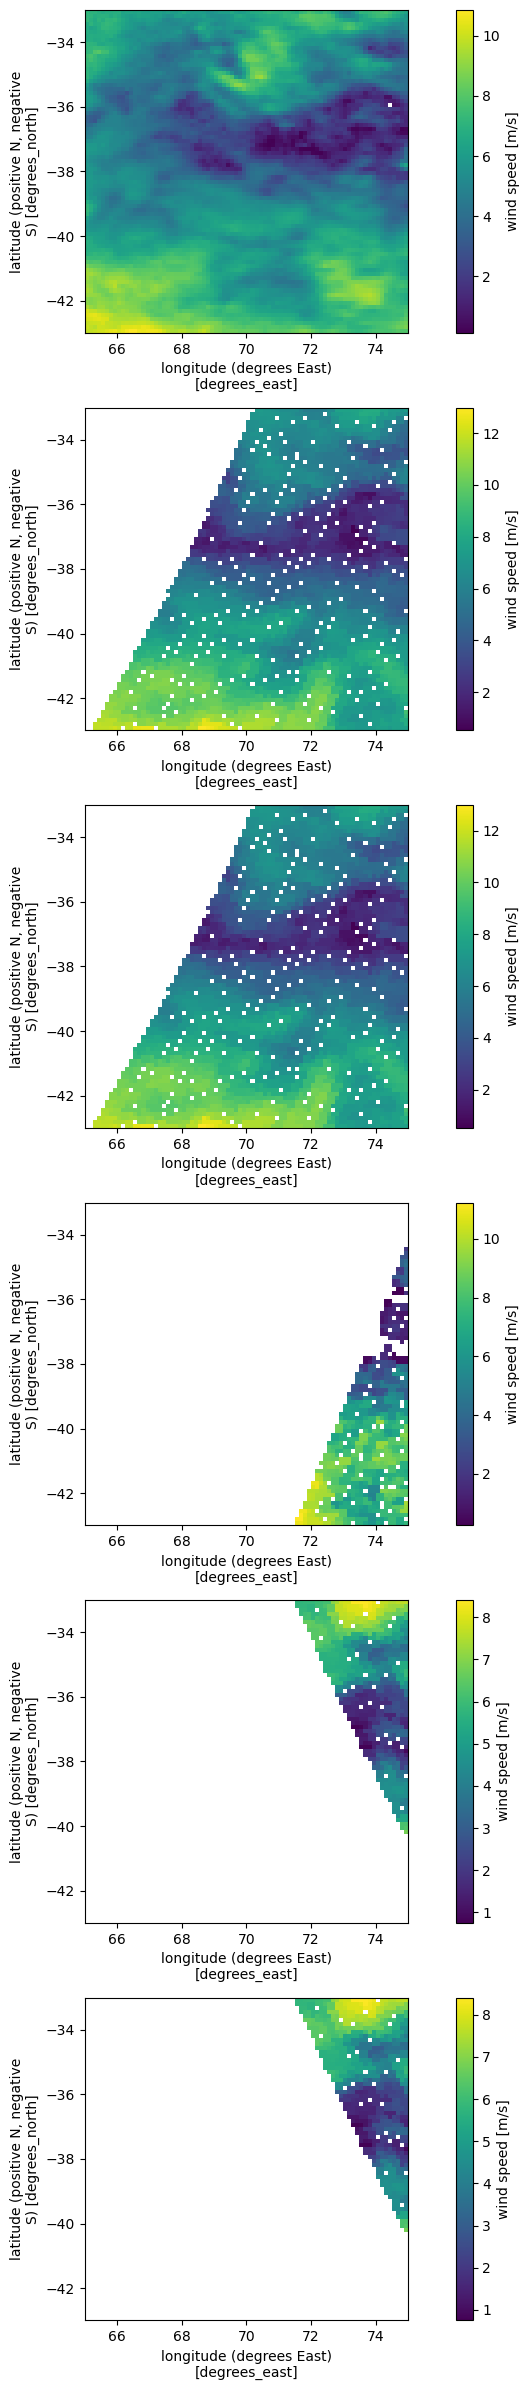

In [181]:
n_orbits = ds_region.sizes['orbit']

fig, axes = plt.subplots(n_orbits, 1, figsize=(10, 4*n_orbits), squeeze=False)

for i in range(n_orbits):
    ax = axes[i, 0]
    ds_region.wind_speed[..., i].T.plot(ax=ax)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()